#Passo a Passo
#1 Entender como o projeto funciona:
  #1 Requesitos:
    # Pandas: para manipulação dos dados 
    # Numpy: Cálculos numérios e operações em arrays 
    # Scikit-learn: Modelos preditivos ( Usando algoritimo como regreção ou árvore de decisão.)
    # Matplotlib: Vizualização dos dados e gráficos e apresentação dos resultados
    # Seaborn: Padrões dos dados financeiros
    #2 Ferramenta e Tecnologias:
      #1 Flet para Interface e app e dasboards
      #2 Python Modelos preditivo
      #3 Git Ferramenta de versionamento para controlar o código e acompanhar atualizações.

#2 Dados:
      #1 Dados históricos para previsão do fluxo de caixa 
      #2 Crie dados com o ChatGPT
      #3 Armazene os dados em CSV 
      #3 Modelagem Preventiva 
     #1 Criar o Modelo Preditivo que analisará fluxo de caixa
       #1 Algoritimo ( Regressão Linear, Random Forest e XGBosost) para previsões temporais
       #2 Treinar modelos: Divida os dados em conjuntos de treino e teste para validar o desemprenho do modelo
       #3 Avaliação: Acompanhar a acurácia do modelos com métricas ( RMSE, MAE e MSE).

     #2 Ferramenta para o treinamento e avaliação dos modelos ( Scikit-learn ou Bibliotecas semelhantes)

#4 Desenvolvimento do sistema com Flet
     #1 Criar uma interface WEB onde a empresa poderá acesar as previssões e tomada de decisões:
       # Painel interativo para exibir previsões 
          # Componente da Interface:
          # Campo para upload de dados financeiros.
          # Visualização das previsões de fluxo de caixa.
          # Dashboard dinâmico com gráficos e indicadores.
          # Botão para exportar relatórios e exportar previsões
       # Funcionalidades: Exibir previsões de fluxo de caixa, gráficos comparativos, e permitir a exportação do relatório para o usuário.

#5 Integração do Modelo com o Sistema
      #1 Objetivo: Fazer a integração do modelo preditivo com o sistema de forma que os dados sejam usados em tempo real para gerar previsões.
       # Ação:
        # Implementação do Back-End: Conecte o modelo preditivo a uma API que recebe os dados financeiros e retorna as previsões.
        # Automatização: Configure um agendador no servidor para rodar previsões regularmente, uma vez por semana ou por mês.
        # Armazenamento de Resultados: Salve os resultados da previsão para que possam ser acessados pelo sistema.

#6 Teste e Validação
     #1 Objetivo : Garantir que o sistema esteja funcionando corretamente e os dados estejam sendo preditivos com qualidade.
        # Testes Locais:  Simule diferentes cenários de entrada de dados e verifique a precisão das previsões.
        # Testes Remotos:  Com dados reais de fluxos de caixa, aplique o sistema e valide as previsões.

#7 Publicação:
     #1 Escolher uma Hospedagem: 


In [123]:

import pandas as pd

In [124]:
tabela = pd.read_csv("fluxo_caixa_empresa.csv", sep=';')
display(tabela.isnull().sum()) # Verificar valores nulos
tabela = tabela.dropna()
tabela ['Saldo'] = tabela['Receitas'] - tabela['Despesas']
display(tabela.head)

      # Grafico para entender os padrões
import matplotlib.pyplot as plt
tabela['Saldo'].plot(kind='line')
plt.show


Data;Receitas;Despesas;Categoria;Região;Cliente_Chave    0
dtype: int64

KeyError: 'Receitas'

In [116]:
# Tratamento de Dados 
# LabelEncoder Codificação de códigos

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

tabela['Categoria'] = label_encoder.fit_transform(tabela['Categoria'])
tabela['Região'] = label_encoder.fit_transform(tabela['Região'])
tabela['Cliente_Chave'] = label_encoder.fit_transform(tabela['Cliente_Chave'])

In [ ]:
# Convertendo a coluna 'DATA' para o formato datetime
tabela['Data'] = pd.to_datetime(tabela['Data'], format='%Y-%m-%d') # Ajuste o formato conforme necessário
# Estraindo caracteristicas temporais
tabela['Ano'] = tabela['Data'].dt.year
tabela['Mes'] = tabela['Data'].dt.month
tabela['Dia'] = tabela['Data'].dt.day

# Verificando as primeiras linhas para confimação
display(tabela[['Data', 'Ano', 'Mes', 'Dia']].head)

<bound method NDFrame.head of           Data   Ano  Mes  Dia
0   2023-01-01  2023    1    1
1   2023-01-02  2023    1    2
2   2023-01-03  2023    1    3
3   2023-01-04  2023    1    4
4   2023-01-05  2023    1    5
..         ...   ...  ...  ...
995 2025-09-22  2025    9   22
996 2025-09-23  2025    9   23
997 2025-09-24  2025    9   24
998 2025-09-25  2025    9   25
999 2025-09-26  2025    9   26

[1000 rows x 4 columns]>

In [118]:
# Recursos (X): para colunas que o modelo usará para aprender e fazer previsões
# Alvo (Y): A coluna que o modelo tentará prever (Saldo ou receita futura)

# Divide os dados em treino e teste

X = tabela.drop(['Data', 'Cliente_Chave', 'Saldo', 'Dia', 'Ano'], axis=1)
y  = tabela['Saldo'] # Apenas Receitas

In [ ]:
#LinearRegression: Cria um modelo de regressão linear.
#train_test_split: Divide os dados em partes de treinamento e teste.
#mean_squared_error e mean_absolute_error: Avaliam a precisão do modelo, verificando o erro entre as previsões e os valores reais.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Verificação de overfitting
from sklearn.model_selection import cross_val_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinando o Modelo
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Prever os valores e avaliação do modelo
pred_lr = model_lr.predict(X_test)

#Avaliação
mse_lr = mean_squared_error(y_test, pred_lr)
mae_lr = mean_absolute_error(y_test, pred_lr)
display(f'Regreção Linear - MSE: {mse_lr}, MAE {mae_lr}')

# Overfitting 
scores = cross_val_score(model_lr, X, y, cv=5, scoring='neg_mean_squared_error')
print(f'Mean MSE (Regressão Linear): {-scores.mean()}')

display(X.dtypes)


'Regreção Linear - MSE: 1.1702240851958107e-22, MAE 9.126068789555576e-12'

Mean MSE (Regressão Linear): 3.379413851631292e-22


Receitas     int64
Despesas     int64
Categoria    int64
Região       int64
Mes          int32
dtype: object

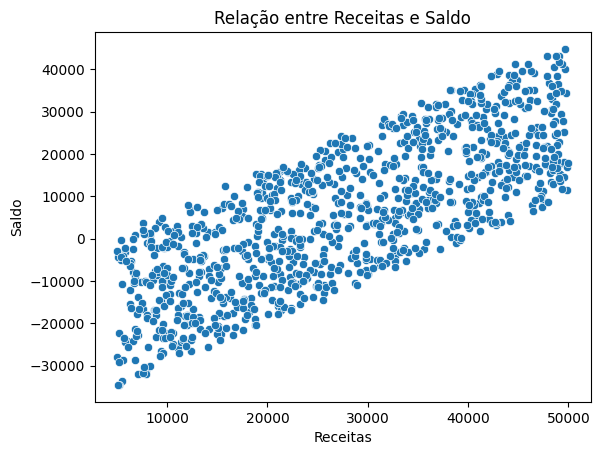

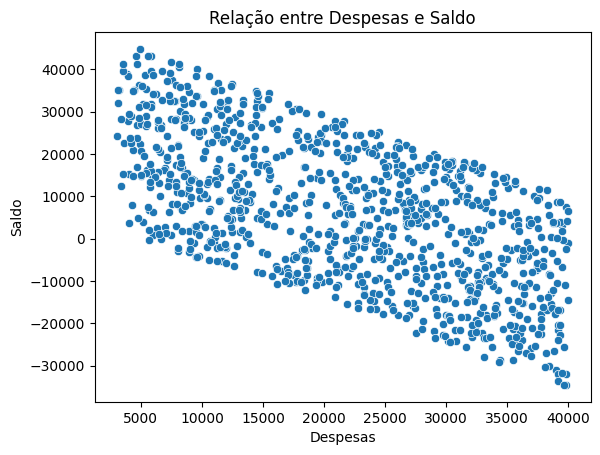

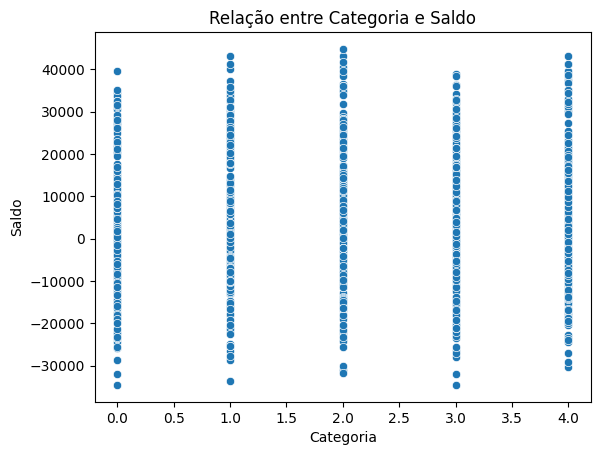

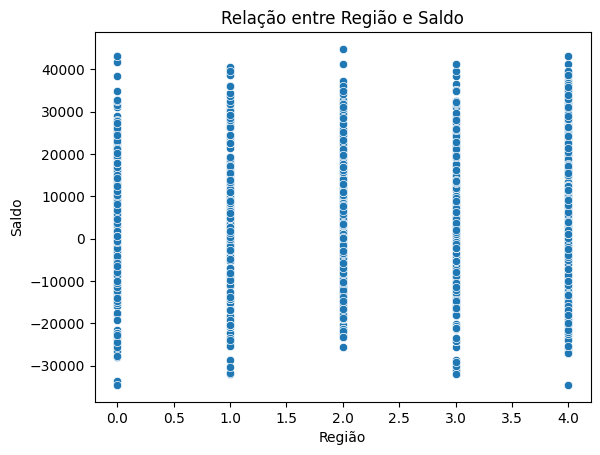

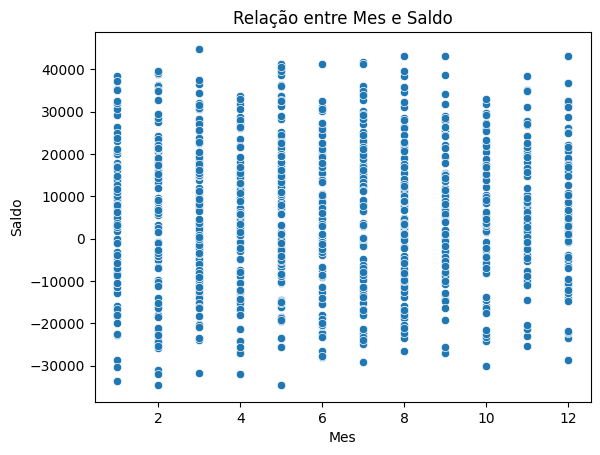

In [ ]:
# Avaliando a Variabilidade dos Dados Overfitting

import seaborn as sns 
for col in X.columns:
    sns.scatterplot(x=tabela[col], y=tabela['Saldo'])
    plt.title(f'Relação entre {col} e Saldo')
    plt.show()

In [ ]:
# Random Forest 

from sklearn.ensemble import RandomForestRegressor

# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar e treinar o modelo
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Prever os valores e avaliar o modelo
pred_rf = model_rf.predict(X_test)

# Avaliação
mse_rf = mean_squared_error(y_test, pred_rf)
mae_rf = mean_absolute_error(y_test, pred_rf)
display(f'Random Forest -  MSE: {mse_rf}, MAE {mae_rf}')

# Validação Cruzada com Random Forest
scores_rf = cross_val_score(model_rf, X, y, cv=5, scoring='neg_mean_squared_error') # 5-fold cross-validation
print(f'mean MSE (Random Forest): {-scores_rf.mean()}')


'Random Forest -  MSE: 746533.8415774998, MAE 649.07035'

mean MSE (Random Forest): 651686.3358779999


In [122]:
# XGBoost

from xgboost import XGBRegressor

# Dividir os dados em treinos e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criando e Treinando o modelo
model_xgb = XGBRegressor(n_estimators=100, random_state=42)
model_xgb.fit(X_train, y_train)

# Prever os valores e avaliação do modelo
pred_xgb = model_xgb.predict(X_test)

# Avaliação
mse_xgb = mean_squared_error(y_test, pred_xgb)
mae_xgb = mean_absolute_error(y_test, pred_xgb)
print(f'XGBoost - MSE: {mse_xgb}, MAE {mae_xgb}')

# Aplicar validação cruzada com KFold
import numpy as np
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores_xgb = []
for train_index, val_index in kfold.split(X, y):
    X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
    y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

    model_xgb.fit(X_train_cv, y_train_cv)
    pred_cv = model_xgb.predict(X_val_cv)

    mse_cv = mean_squared_error(y_val_cv, pred_cv)
    scores_xgb.append(mse_cv)
print(f'Mean MSE (XGBoost KFold): {np.mean(scores_xgb)}')


XGBoost - MSE: 742426.375, MAE 674.9615478515625
Mean MSE (XGBoost KFold): 949704.325
